In [ ]:
# Section 1: Import Libraries
# Import core data manipulation libraries
import pandas as pd
import numpy as np

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import NLP and string manipulation libraries
import re
import nltk
from nltk.corpus import stopwords

# Download standard NLTK packages needed for text processing
# 'stopwords' gives us a list of common English words to filter out
# 'punkt' is used for tokenization (splitting text into words)
nltk.download('stopwords')
nltk.download('punkt')

print("All libraries imported successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


All libraries imported successfully!


In [ ]:
# Section 2: Load Dataset
# Use just the filename if uploaded directly to Colab
file_path = 'LinkedIn_RDB_three.csv'

# Load the dataset into a pandas DataFrame
df = pd.read_csv(file_path)

# Display the first 5 rows
df.head()

,job_id,title,description,pay_period,work_type,job_location,applies,remote_allowed,views,level,sponsored,compensation,job_domain,company_id,ben_pack_id
0,903408693,Office Associate,Provide clerical and administrative support to...,YEARLY,Full-time,"Albany, GA",5,False,49,NaN,True,"$42,000.00",Administration,3894635,1.0
1,1029078768,Registered Nurse (RN) Vaccinator,United Staffing Solutions is partnering with o...,HOURLY,Part-time,"Muskegon, MI",0,False,4,NaN,False,"$104,000.00",Healthcare,61469,1.0
2,1657978824,"REMOTE STEEL BUILDING SALES MAKE $1,000 TO $30...","REMOTE WORK FROM HOME $1,000 TO $10,000 COMMIS...",MONTHLY,Contract,"Texas, United States",0,True,0,NaN,False,"$144,000.00",Other,89350959,1.0
3,2148434033,Contract Bilingual Recruiter,"Location: Phoenix, AZ 85006---- IN OFFICE JOB ...",YEARLY,Contract,"Phoenix, AZ",0,False,0,Associate,False,"$65,000.00",Human Resources,1082195,1.0
4,2148434586,"Manager, Salesforce Platform",Invitation Homes is a fast-paced evolving publ...,YEARLY,Full-time,"New Hampshire, United States",0,False,0,Mid-Senior level,False,"$170,976.00",Information Technology,2780388,113.0


In [ ]:
# Section 3: Dataset Overview
# 1. Check the dimensions of the dataset (rows, columns)
print("--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

# 2. List all column names to see what features we have
print("--- Column Names ---")
print(df.columns.tolist())
print("\n")

# 3. Display data types and check for initial non-null counts
print("--- Dataset Info ---")
df.info()
print("\n")

# 4. Generate basic statistics for numerical columns (like views, applies, company_id)
print("--- Statistical Summary ---")
# Using display() instead of print() renders a nice HTML table in Colab
display(df.describe())

--- Dataset Shape ---
Rows: 6328, Columns: 15

--- Column Names ---
['job_id', 'title', 'description', 'pay_period', 'work_type', 'job_location', 'applies', 'remote_allowed', 'views', 'level', 'sponsored', 'compensation', 'job_domain', 'company_id', 'ben_pack_id']


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6328 entries, 0 to 6327
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   job_id          6328 non-null   int64  
 1   title           6328 non-null   object 
 2   description     6328 non-null   object 
 3   pay_period      6328 non-null   object 
 4   work_type       6328 non-null   object 
 5   job_location    6328 non-null   object 
 6   applies         6328 non-null   int64  
 7   remote_allowed  6328 non-null   bool   
 8   views           6328 non-null   int64  
 9   level           4520 non-null   object 
 10  sponsored       6328 non-null   bool   
 11  compensation   

,job_id,applies,views,company_id,ben_pack_id
count,6.328000e+03,6328.000000,6328.000000,6.328000e+03,6327.000000
mean,3.692362e+09,15.309735,76.117415,9.854270e+06,31.136716
std,8.051121e+07,45.276299,173.798446,2.232414e+07,42.069630
min,9.034087e+08,0.000000,0.000000,1.009000e+03,1.000000
25%,3.693071e+09,0.000000,3.000000,1.105600e+04,1.000000
50%,3.697355e+09,2.000000,21.000000,1.659680e+05,1.000000
75%,3.699409e+09,11.000000,78.000000,4.822178e+06,49.000000
max,3.701374e+09,1420.000000,5656.000000,9.856222e+07,173.000000


In [ ]:
# Section 4: Missing Value Analysis
# 1. Calculate the total number of missing values per column
missing_counts = df.isnull().sum()

# 2. Calculate the percentage of missing values per column
missing_percentage = (missing_counts / len(df)) * 100

# 3. Combine counts and percentages into a new DataFrame for a professional display
missing_data = pd.DataFrame({
    'Missing Values': missing_counts,
    'Percentage (%)': missing_percentage.round(2) # Round to 2 decimal places
})

# 4. Filter the table to show ONLY the columns that actually have missing data
# and sort them from highest percentage to lowest.
missing_data = missing_data[missing_data['Missing Values'] > 0].sort_values(by='Percentage (%)', ascending=False)

print("--- Missing Value Analysis ---")
display(missing_data)

--- Missing Value Analysis ---


,Missing Values,Percentage (%)
level,1808,28.57
job_domain,123,1.94
ben_pack_id,1,0.02


In [ ]:
# Section 5: Duplicate Detection
# 1. Count the number of exact duplicate rows in the dataset
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

# 2. Remove duplicates (if any exist) to ensure data integrity
# The 'inplace=True' argument modifies the existing DataFrame directly rather than creating a copy
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicates removed. New dataset shape: {df.shape}")
else:
    print("No duplicates to remove. The dataset is structurally unique.")

Number of duplicate rows found: 0
No duplicates to remove. The dataset is structurally unique.


In [ ]:
# Section 6: Data Cleaning
print("--- Starting Data Cleaning ---")

# 1. Remove unnecessary leading/trailing whitespace from all text columns
text_columns = ['title', 'description', 'pay_period', 'work_type', 'job_location', 'level', 'job_domain', 'compensation']
for col in text_columns:
    if col in df.columns:
        # Check if the column is of object (string) type before stripping
        if df[col].dtype == 'object':
            df[col] = df[col].str.strip()

print("1. Whitespace removed from text columns.")

# 2. Clean the 'compensation' column and convert to numeric
if 'compensation' in df.columns:
    # Remove the dollar sign '$'
    df['compensation'] = df['compensation'].str.replace('$', '', regex=False)
    # Remove the commas ','
    df['compensation'] = df['compensation'].str.replace(',', '', regex=False)
    # Convert the cleaned string to a float numeric type
    # errors='coerce' turns any completely invalid parsing into NaN
    df['compensation'] = pd.to_numeric(df['compensation'], errors='coerce')

print("2. Compensation column cleaned and converted to numeric.")

# 3. Handle missing values appropriately
if 'level' in df.columns:
    df['level'] = df['level'].fillna('Not Specified')

if 'job_domain' in df.columns:
    df['job_domain'] = df['job_domain'].fillna('Not Specified')

if 'ben_pack_id' in df.columns:
    # Since it's a numeric ID, we fill the single missing value with 0.0
    df['ben_pack_id'] = df['ben_pack_id'].fillna(0.0)

print("3. Missing values filled with placeholders ('Not Specified').")

# Verify the changes by checking info and the cleaned compensation column
print("\n--- Cleaning Verification ---")
print(f"Missing levels after cleaning: {df['level'].isnull().sum()}")
print(f"Compensation data type: {df['compensation'].dtype}")
display(df[['title', 'compensation', 'level']].head())

--- Starting Data Cleaning ---
1. Whitespace removed from text columns.
2. Compensation column cleaned and converted to numeric.
3. Missing values filled with placeholders ('Not Specified').

--- Cleaning Verification ---
Missing levels after cleaning: 0
Compensation data type: float64


,title,compensation,level
0,Office Associate,42000.0,Not Specified
1,Registered Nurse (RN) Vaccinator,104000.0,Not Specified
2,"REMOTE STEEL BUILDING SALES MAKE $1,000 TO $30...",144000.0,Not Specified
3,Contract Bilingual Recruiter,65000.0,Associate
4,"Manager, Salesforce Platform",170976.0,Mid-Senior level


In [ ]:
# Section 7: Basic NLP Preprocessing
print("--- Starting NLP Preprocessing ---")

# 1. Define the English stopwords list
stop_words = set(stopwords.words('english'))

# 2. Define our normalization dictionary for common tech variations
skill_normalization = {
    r'\breactjs\b': 'react',
    r'\breact\.js\b': 'react',
    r'\bjavascript\b': 'javascript', # Ensuring standard casing later if needed, but keeping lowercase for matching
    r'\bnodejs\b': 'node.js',
    r'\bnode\.js\b': 'node.js',
    r'\bamazon web services\b': 'aws',
    r'\bgcp\b': 'google cloud',
    r'\bms excel\b': 'excel'
}

# 3. Define a predefined list of target skills we want to extract (all lowercase for matching)
# In a full project, this list would be much longer or loaded from a separate file.
target_skills = [
    'python', 'sql', 'java', 'c++', 'c#', 'javascript', 'html', 'css',
    'react', 'node.js', 'aws', 'azure', 'google cloud', 'docker',
    'kubernetes', 'machine learning', 'data analysis', 'excel', 'tableau',
    'power bi', 'agile', 'scrum', 'leadership', 'communication'
]

# Function to clean text
def clean_text(text):
    if not isinstance(text, str):
        return ""

    # Convert to lowercase
    text = text.lower()

    # Normalize specific skill names using regex substitution
    for pattern, replacement in skill_normalization.items():
        text = re.sub(pattern, replacement, text)

    # Remove punctuation (keep alphanumeric and spaces, plus periods for things like node.js)
    # We use a simple regex to replace anything that isn't a letter, number, space, or dot.
    text = re.sub(r'[^a-z0-9\s\.]', ' ', text)

    # Tokenize (split into words) and remove stopwords
    words = text.split()
    cleaned_words = [word for word in words if word not in stop_words]

    # Rejoin into a single string
    return ' '.join(cleaned_words)

# Function to extract skills
def extract_skills(cleaned_text):
    extracted = []
    for skill in target_skills:
        # We use word boundaries \b so we don't match "c" inside "mac"
        # However, for special characters like ++ or #, standard \b might fail,
        # so we do a simple substring check for this college project context.
        if skill in cleaned_text:
            # Capitalize the first letter for a cleaner final look (e.g., 'python' -> 'Python')
            # Custom rules for specific acronyms
            if skill == 'aws':
                extracted.append('AWS')
            elif skill == 'sql':
                extracted.append('SQL')
            elif skill == 'html':
                extracted.append('HTML')
            elif skill == 'css':
                extracted.append('CSS')
            else:
                extracted.append(skill.title())

    return extracted

# 4. Apply the cleaning function to the description column
# We create a new column 'cleaned_description' to preserve the original data
print("Cleaning job descriptions (this may take a few seconds)...")
df['cleaned_description'] = df['description'].apply(clean_text)

# 5. Apply the extraction function to pull out the skills
print("Extracting skills...")
df['extracted_skills'] = df['cleaned_description'].apply(extract_skills)

print("\n--- NLP Preprocessing Complete ---")
# Display the results
display(df[['title', 'description', 'extracted_skills']].head())

--- Starting NLP Preprocessing ---
Cleaning job descriptions (this may take a few seconds)...
Extracting skills...

--- NLP Preprocessing Complete ---


,title,description,extracted_skills
0,Office Associate,Provide clerical and administrative support to...,[Communication]
1,Registered Nurse (RN) Vaccinator,United Staffing Solutions is partnering with o...,[]
2,"REMOTE STEEL BUILDING SALES MAKE $1,000 TO $30...","REMOTE WORK FROM HOME $1,000 TO $10,000 COMMIS...",[]
3,Contract Bilingual Recruiter,"Location: Phoenix, AZ 85006---- IN OFFICE JOB ...",[]
4,"Manager, Salesforce Platform",Invitation Homes is a fast-paced evolving publ...,"[Excel, Communication]"


--- Starting Skill Frequency Analysis ---

--- Top 15 Most In-Demand Skills ---


,Frequency
extracted_skills,
Communication,3570
Excel,3362
Leadership,1573
AWS,1083
SQL,382
Agile,369
Python,303
Data Analysis,239
Java,217


/tmp/ipykernel_3389/1508487111.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=skill_counts.values, y=skill_counts.index, palette='viridis')


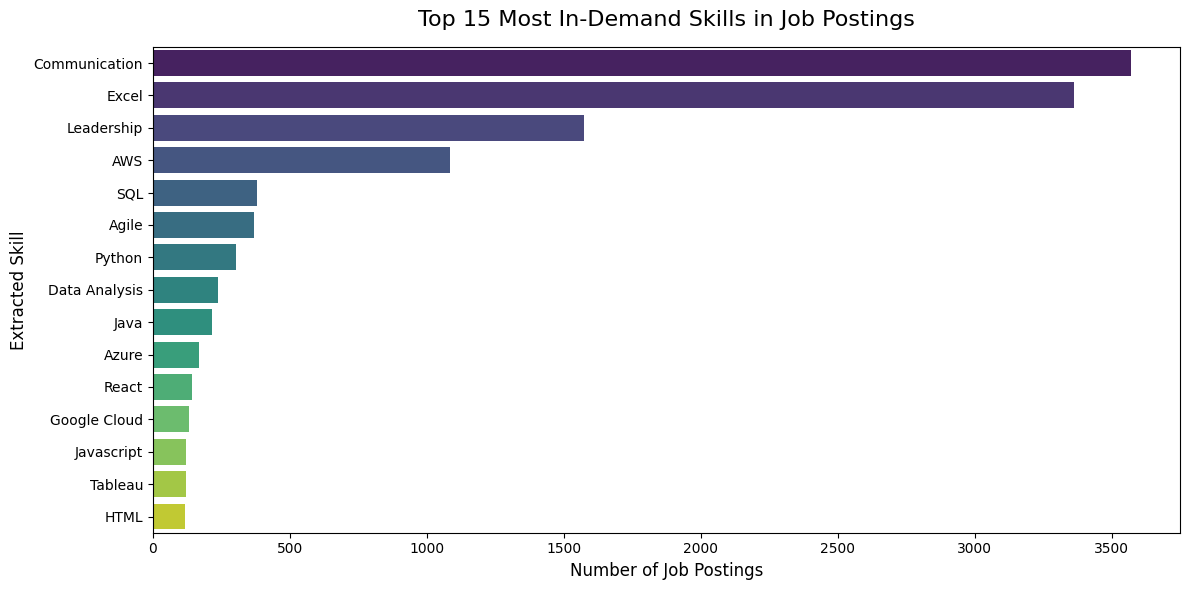

In [ ]:
# Section 8: Frequency Analysis & Visualization
print("--- Starting Skill Frequency Analysis ---")

# 1. Flatten the list of skills.
# The explode() function takes a list like ['Python', 'SQL'] and turns it into two separate rows.
all_skills = df['extracted_skills'].explode()

# 2. Remove any empty values (rows where no skills were extracted)
all_skills = all_skills.dropna()

# 3. Count the occurrences of each skill and take the top 15
skill_counts = all_skills.value_counts().head(15)

print("\n--- Top 15 Most In-Demand Skills ---")
# Display as a clean dataframe
display(skill_counts.to_frame(name='Frequency'))

# 4. Create a professional Bar Chart
plt.figure(figsize=(12, 6)) # Set the size of the canvas

# Use Seaborn to create a horizontal bar plot for readability
# We use the 'viridis' color palette for a modern, professional look
sns.barplot(x=skill_counts.values, y=skill_counts.index, palette='viridis')

# Add titles and axis labels
plt.title('Top 15 Most In-Demand Skills in Job Postings', fontsize=16, pad=15)
plt.xlabel('Number of Job Postings', fontsize=12)
plt.ylabel('Extracted Skill', fontsize=12)

# Adjust layout so labels don't get cut off, then display the plot
plt.tight_layout()
plt.show()

In [ ]:
# Section 9: Export Clean Dataset
print("--- Exporting Cleaned Dataset ---")

# Define the output file name
output_file = 'linkedin_jobs_cleaned.csv'

# Save the DataFrame to a new CSV file.
# We set 'index=False' so pandas doesn't write the row numbers as a new, unnecessary column.
df.to_csv(output_file, index=False)

print(f"Success! The cleaned dataset has been saved as: {output_file}")
print("You can now download this file from the Colab file explorer and use it in your Streamlit application.")

--- Exporting Cleaned Dataset ---
Success! The cleaned dataset has been saved as: linkedin_jobs_cleaned.csv
You can now download this file from the Colab file explorer and use it in your Streamlit application.
